In [37]:

import re
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime as dt
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, IterativeImputer, KNNImputer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

In [35]:
df = pd.read_csv('data/titanic.csv', usecols=['Age', 'Fare', 'Embarked', 'Survived'])
df.head()

,Survived,Age,Fare,Embarked
0,0,22.0,7.2500,S
1,1,38.0,71.2833,C
2,1,26.0,7.9250,S
3,1,35.0,53.1000,S
4,0,35.0,8.0500,S


In [9]:
df.isnull().mean()*100

Survived     0.000000
Age         19.865320
Fare         0.000000
Embarked     0.224467
dtype: float64

Age has 19 % missing value and Embarked has 0.22 % missing value

In [33]:
X = df[['Age', 'Fare', 'Embarked']]
y =  df['Survived']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 0)

# Simple Imputer

In [20]:
num_imputer = SimpleImputer(strategy= 'median', add_indicator=True) # for numarical imputation, add_indicator will add an missing indicator
cat_imputer = SimpleImputer(strategy='most_frequent')

X_train['Age'] = num_imputer.fit_transform(X_train[['Age']])
X_test['Age'] = num_imputer.transform(X_test[['Age']])

X_train['Embarked'] = cat_imputer.fit_transform(X_train[['Embarked']]).ravel()
X_test['Embarked'] = cat_imputer.transform(X_test[['Embarked']]).ravel()

X_train.isnull().sum()

Age         0
Fare        0
Embarked    0
dtype: int64

# Random Sample Imputation

The benefit of this imputation is that it keeps the distribution of the data

In [ ]:
df.loc[df['Age'].isnull(), 'Age_imputed'] = df['Age'].dropna().sample(df['Age'].isnull().sum()).values
df.loc[df['Embarked'].isnull(), 'Embarked_imputed'] = df['Embarked'].dropna().sample(df['Embarked'].isnull().sum()).values
df.isnull().sum()

Survived              0
Age                 177
Fare                  0
Embarked              2
Age_imputed         714
Embarked_imputed    889
dtype: int64

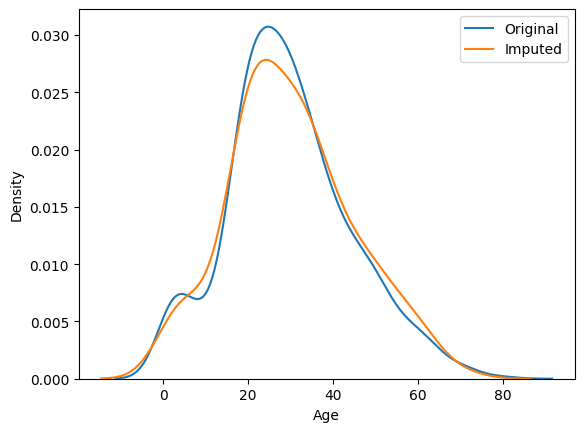

In [40]:
sns.kdeplot(df['Age'], label = 'Original')
sns.kdeplot(df['Age_imputed'], label = 'Imputed')
plt.legend()
plt.show()

# Iterative Imputation

In [28]:
car = pd.read_csv('data/car_details.csv', usecols=['mileage', 'engine', 'torque', 'max_power', 'year'])

car['mileage'] = car['mileage'].str.extract(r'(\d+\.?\d*)').astype(float)
car['car_age'] = dt.now().year - car['year']
car.drop(columns = ['year'], inplace = True)
car['engine'] = car['engine'].str.extract(r'(\d+\.?\d*)').astype(float)
car['max_power'] = car['max_power'].str.extract(r'(\d+\.?\d*)').astype(float)
def extract_torque(val):
    if pd.isna(val):
        return np.nan
    val = str(val).replace(',', '') 
    match = re.search(r'(\d+\.?\d*)\s*(Nm|kgm)', val, re.IGNORECASE)
    if not match:
        return np.nan
    number, unit = float(match.group(1)), match.group(2).lower()
    if unit == 'kgm':
        number = number * 9.8
    return number

car['torque'] = car['torque'].apply(extract_torque)
car.head()

,mileage,engine,max_power,torque,car_age
0,23.40,1248.0,74.00,190.00,12
1,21.14,1498.0,103.52,250.00,12
2,17.70,1497.0,78.00,NaN,20
3,23.00,1396.0,90.00,219.52,16
4,16.10,1298.0,88.20,NaN,19


In [29]:
car.isnull().sum()

mileage      221
engine       221
max_power    216
torque       627
car_age        0
dtype: int64

In [30]:
car.corr()

,mileage,engine,max_power,torque,car_age
mileage,1.000000,-0.575831,-0.374621,-0.279397,-0.329145
engine,-0.575831,1.000000,0.703975,0.752151,-0.018848
max_power,-0.374621,0.703975,1.000000,0.840997,-0.226320
torque,-0.279397,0.752151,0.840997,1.000000,-0.174975
car_age,-0.329145,-0.018848,-0.226320,-0.174975,1.000000


All these columns are very correlated so Simple imputer doesn't perform well 

so we need to use iterative imputer

In [32]:
iter = IterativeImputer(estimator=RandomForestRegressor(n_estimators=10, random_state=0), max_iter=100, random_state= 0)

new_car = pd.DataFrame(iter.fit_transform(car), columns= iter.get_feature_names_out())

new_car.isnull().sum()

C:\Users\Keval\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\impute\_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


mileage      0
engine       0
max_power    0
torque       0
car_age      0
dtype: int64